# WO1 — Within-polity-variance ranking

**Goal:** For three static BasinATLAS baselines, rank every Cliopatria polity extent by the internal spread of that variable across its member L06 basins. Produces the hero-shot shortlist: gradient-straddling polities where the choropleth will show obvious environmental drama.

**Variables:** aridity index (primary), annual precipitation, mean elevation.

**Method:** centroid-in basin membership; PERCENT_RANK scores commensurable with choropleth; p90–p10 as primary spread key; roll up to polity name (max spread across slices).

**Accept gate:** Northern Song lands in the top ~10–15% by aridity spread.

In [3]:
# Cell 1
%matplotlib inline
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore', message='.*SQLAlchemy.*', category=UserWarning)

sys.path.insert(0, '../../../..')
import scripts.shared.db_utils as _dbu

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'demo'
OUT.mkdir(parents=True, exist_ok=True)

conn = _dbu.db_connect()
print(f'Connected. Output -> {OUT}')

Connected. Output -> /Users/karlg/Documents/repos/_edops/output/edop/demo


In [4]:
# Cell 2 — variable audit
# Confirm the three BasinATLAS columns exist in basin06; inspect NoData coverage and range.

NODATA = -9999
VARS = [
    ('aridity_index',       'ari_ix_sav',  'P/PET x100; higher = wetter'),
    ('precipitation_annual','pre_mm_syr',  'mm/yr; sub-basin mean'),
    ('elevation_mean',      'ele_mt_sav',  'm a.s.l.; sub-basin mean'),
]

rows = []
for schema_key, col, note in VARS:
    df = pd.read_sql(f"""
        SELECT COUNT(*)                                       AS n_total,
               COUNT(CASE WHEN {col} = {NODATA} THEN 1 END)  AS n_nodata,
               MIN(CASE WHEN {col} != {NODATA} THEN {col} END)  AS vmin,
               MAX(CASE WHEN {col} != {NODATA} THEN {col} END)  AS vmax,
               AVG(CASE WHEN {col} != {NODATA} THEN {col} END)  AS vmean
        FROM public.basin06
    """, conn)
    r = df.iloc[0]
    rows.append({'variable': schema_key, 'col': col,
                 'n_total': int(r.n_total), 'n_nodata': int(r.n_nodata),
                 'pct_nodata': round(100 * r.n_nodata / r.n_total, 2),
                 'vmin': round(float(r.vmin), 2), 'vmax': round(float(r.vmax), 2),
                 'vmean': round(float(r.vmean), 2), 'note': note})

audit = pd.DataFrame(rows)
print(audit[['variable', 'col', 'n_total', 'n_nodata', 'pct_nodata', 'vmin', 'vmax', 'vmean']].to_string(index=False))

            variable        col  n_total  n_nodata  pct_nodata  vmin   vmax  vmean
       aridity_index ari_ix_sav    16397         0         0.0   0.0 2101.0  84.21
precipitation_annual pre_mm_syr    16397         0         0.0   0.0 6872.0 771.53
      elevation_mean ele_mt_sav    16397         0         0.0 -30.0 5556.0 613.38


In [5]:
# Cell 3 — basin-level PERCENT_RANK scores
# One row per basin; three percentile columns (0–100 scale).
# Ordering: ascending = lower = drier / drier / lower elevation.
# Consistent with representative_score semantics in the EDOPS signature.
# NoData basins receive NULL (excluded from window; no score assigned).

basin_scores = pd.read_sql("""
    WITH raw AS (
        SELECT hybas_id,
               CASE WHEN ari_ix_sav = -9999 THEN NULL ELSE ari_ix_sav END AS aridity_raw,
               CASE WHEN pre_mm_syr = -9999 THEN NULL ELSE pre_mm_syr END AS precip_raw,
               CASE WHEN ele_mt_sav = -9999 THEN NULL ELSE ele_mt_sav END AS elev_raw
        FROM public.basin06
    )
    SELECT hybas_id,
           PERCENT_RANK() OVER (ORDER BY aridity_raw NULLS LAST) * 100 AS aridity_pct,
           PERCENT_RANK() OVER (ORDER BY precip_raw  NULLS LAST) * 100 AS precip_pct,
           PERCENT_RANK() OVER (ORDER BY elev_raw    NULLS LAST) * 100 AS elev_pct
    FROM raw
""", conn)

print(f'Basin scores: {len(basin_scores):,} rows')
print()
print(basin_scores[['aridity_pct', 'precip_pct', 'elev_pct']].describe().round(2))

Basin scores: 16,397 rows

       aridity_pct  precip_pct  elev_pct
count     16397.00    16397.00  16397.00
mean         49.68       49.97     49.95
std          29.01       28.89     28.90
min           0.00        0.00      0.00
25%          24.92       24.98     24.97
50%          49.53       49.89     50.00
75%          74.76       74.99     74.98
max         100.00      100.00    100.00


In [6]:
# Cell 4 — polity-basin membership (centroid-in)
# Basin belongs to a polity slice if its centroid lies within the polity geometry.
# Excludes component polities (sub-units of larger extents) and invalid source geoms.
# DISTINCT guards against any edge geometry re-capturing the same basin centroid twice.
# This join is the most expensive step; expect ~30–90 s depending on GIST cache state.

print('Running spatial join (centroid-in)... this may take a minute.')

membership = pd.read_sql("""
    SELECT DISTINCT
           p.id        AS polity_id,
           p.name,
           p.fromyear,
           p.toyear,
           b.hybas_id
    FROM gaz.clio_polities p
    JOIN public.basin06   b
      ON ST_Within(ST_Centroid(b.geom), p.geom)
    WHERE NOT p.is_component
      AND NOT p.invalid_source_geom
""", conn)

print(f'Membership rows:      {len(membership):,}')
print(f'Polity slices joined: {membership["polity_id"].nunique():,}')
print(f'Unique polity names:  {membership["name"].nunique():,}')
print(f'Basins assigned:      {membership["hybas_id"].nunique():,} / 16,397')
print()

n_per_slice = membership.groupby('polity_id')['hybas_id'].count()
print('Basins per polity slice:')
print(n_per_slice.describe().round(1))

Membership rows:      1,223,239
Polity slices joined: 10,607
Unique polity names:  1,327
Basins assigned:      15,142 / 16,397

Basins per polity slice:
count    10607.0
mean       115.3
std        311.8
min          1.0
25%          5.0
50%         20.0
75%         75.0
max       3334.0
Name: hybas_id, dtype: float64


In [7]:
# Cell 5 — spread per polity slice
# Join basin scores onto membership; compute spread stats per polity slice for all 3 vars.
# Primary rank key: p90 - p10 (robust to outlier basins; legible as a percentile span).
# n_basins is carried through so tiny-extent polities stay visible in the rollup.

mem_scores = membership.merge(
    basin_scores[['hybas_id', 'aridity_pct', 'precip_pct', 'elev_pct']],
    on='hybas_id', how='inner'
)
print(f'Joined rows: {len(mem_scores):,}  (dropped {len(membership) - len(mem_scores)} unscored basins)')

def polity_spread(group):
    out = {'n_basins': len(group)}
    for var in ('aridity', 'precip', 'elev'):
        v = group[f'{var}_pct'].dropna()
        n = len(v)
        if n >= 2:
            out[f'{var}_spread'] = round(float(np.percentile(v, 90) - np.percentile(v, 10)), 3)
            out[f'{var}_sd']     = round(float(v.std()), 3)
            out[f'{var}_min']    = round(float(v.min()), 2)
            out[f'{var}_max']    = round(float(v.max()), 2)
            out[f'{var}_median'] = round(float(v.median()), 2)
        else:
            for s in ('spread', 'sd', 'min', 'max', 'median'):
                out[f'{var}_{s}'] = None
    return pd.Series(out)

per_slice = (
    mem_scores
    .groupby(['polity_id', 'name', 'fromyear', 'toyear'])
    [['aridity_pct', 'precip_pct', 'elev_pct']]
    .apply(polity_spread)
    .reset_index()
)
print(f'\nPer-slice spread table: {len(per_slice):,} rows')
print(per_slice[['aridity_spread', 'precip_spread', 'elev_spread', 'n_basins']].describe().round(2))


Per-slice spread table: 10,607 rows
       aridity_spread  precip_spread  elev_spread  n_basins
count         9670.00        9670.00      9670.00  10607.00
mean            24.82          22.19        40.43    115.32
std             18.54          18.82        24.65    311.83
min              0.00           0.00         0.00      1.00
25%             10.26           8.38        18.94      5.00
50%             20.73          16.49        40.34     20.00
75%             35.46          31.31        60.12     75.00
max             96.81          95.06        97.16   3334.00


In [8]:
# Cell 6 — roll up to polity name; ACCEPT GATE — Northern Song aridity rank
# Roll up: for each polity name, take the slice with the highest aridity spread.
# Minimum n_basins threshold documented; show sensitivity to the choice.
# Accept gate: N Song in top ~10-15% of multi-basin polities.

MIN_BASINS = 5  # single/tiny extents are weak straddle stories

def rollup(per_slice_df, var, min_basins=MIN_BASINS):
    spread_col = f'{var}_spread'
    eligible = per_slice_df[per_slice_df['n_basins'] >= min_basins].dropna(subset=[spread_col])
    # Slice with highest spread for each polity name
    idx = eligible.groupby('name')[spread_col].idxmax()
    ranked = eligible.loc[idx].copy().reset_index(drop=True)
    ranked['rank'] = ranked[spread_col].rank(ascending=False, method='min').astype(int)
    ranked = ranked.sort_values(spread_col, ascending=False).reset_index(drop=True)
    return ranked

aridity_ranked = rollup(per_slice, 'aridity')
n_total = len(aridity_ranked)

print(f'=== ARIDITY SPREAD — top 25 (n_basins >= {MIN_BASINS}) ===')
cols = ['name', 'aridity_spread', 'aridity_sd', 'n_basins', 'fromyear', 'toyear', 'aridity_min', 'aridity_max']
print(aridity_ranked.head(25)[cols].to_string(index=True))

print(f'\n--- ACCEPT GATE: Northern Song ---')
nsong = aridity_ranked[aridity_ranked['name'].str.contains('Song', case=False, na=False)]
if len(nsong):
    r = nsong.iloc[0]
    pct = 100 * r['rank'] / n_total
    print(f'  Name:   {r["name"]}')
    print(f'  Rank:   {r["rank"]} / {n_total}  (top {pct:.1f}%)')
    print(f'  Spread: {r["aridity_spread"]:.2f} pct-pts  (p90 - p10)')
    print(f'  n_basins: {r["n_basins"]:.0f}  |  years: {r["fromyear"]}–{r["toyear"]}')
    gate = pct <= 15
    print(f'  GATE: {"PASS" if gate else "FAIL"}  (threshold: top 15%)')
else:
    print('  N Song not found (check n_basins filter or name matching)')

=== ARIDITY SPREAD — top 25 (n_basins >= 5) ===
                            name  aridity_spread  aridity_sd  n_basins  fromyear  toyear  aridity_min  aridity_max
0              Republic of Chile          96.813      41.448      87.0      1885    1904         0.00        99.32
1       Kingdom of Great Britain          93.450      43.155     111.0      1941    1941         3.24        98.95
2               Kingdom of Spain          89.178      32.970     127.0      1898    1899         1.48        97.66
3               Republic of Peru          88.667      33.817      57.0      1834    1835         0.00        93.02
4        British Colonial Empire          87.168      37.234     221.0      1946    1946         3.24        98.46
5                 Spanish Empire          85.112      31.412     396.0      1552    1555         0.00        98.71
6    Peru-Bolivian Confederation          83.656      30.313     148.0      1836    1839         0.00        93.02
7                   Tang Dynasty

In [10]:
# Cell 6b — expansion-into-gradient: N Song analogs
# The N Song pattern is spread INCREASING over slices as the territory expands
# across an environmental boundary. The rollup-by-max in Cell 6 cannot distinguish
# "always high" from "grew into it." Here: filter to polities with >= 3 slices,
# compute spread trajectory per polity, rank by (spread_last - spread_first).
# Monotone-increasing polities are the cleanest analogs: each territorial change
# carries the extent further into the gradient.

MIN_SLICES   = 3
MIN_BASINS_T = 5
NSONG_NAME   = 'Northern Song'   # exact name; str.contains catches Songhai, Liu Song, etc.

traj_base = (per_slice[per_slice['n_basins'] >= MIN_BASINS_T]
             .dropna(subset=['aridity_spread'])
             .sort_values(['name', 'fromyear']))

slice_counts = traj_base.groupby('name').size()
multi_names  = slice_counts[slice_counts >= MIN_SLICES].index
traj_base    = traj_base[traj_base['name'].isin(multi_names)].copy()

def trajectory_stats(group):
    g = group.sort_values('fromyear')
    s = g['aridity_spread'].values
    y = g['fromyear'].values
    n = len(s)
    slope = float(np.polyfit(y, s, 1)[0]) if y[-1] > y[0] else 0.0
    mono  = all(s[i] <= s[i + 1] for i in range(n - 1))
    return pd.Series({
        'n_slices':     n,
        'spread_first': round(float(s[0]), 2),
        'spread_last':  round(float(s[-1]), 2),
        'spread_delta': round(float(s[-1] - s[0]), 2),
        'spread_max':   round(float(s.max()), 2),
        'slope_per_yr': round(slope, 5),
        'monotone_inc': mono,
        'year_first':   int(y[0]),
        'year_last':    int(y[-1]),
        'n_basins_max': int(g['n_basins'].max()),
    })

traj_stats = (
    traj_base
    .groupby('name')[['fromyear', 'toyear', 'aridity_spread', 'n_basins']]
    .apply(trajectory_stats)
    .reset_index()
    .sort_values('spread_delta', ascending=False)
)

TCOLS = ['name', 'spread_delta', 'spread_first', 'spread_last', 'spread_max',
         'n_slices', 'year_first', 'year_last', 'n_basins_max', 'monotone_inc']

print(f'Polities with >= {MIN_SLICES} slices (n_basins >= {MIN_BASINS_T}): {len(traj_stats):,}')
print()
print('=== TOP 20 BY SPREAD DELTA (last - first) ===')
print(traj_stats.head(20)[TCOLS].to_string(index=True))

print()
print('=== MONOTONE INCREASING — top 15 ===')
mono = traj_stats[traj_stats['monotone_inc']].head(15)
print(mono[TCOLS].to_string(index=True))

# N Song validation — exact name match
print()
nsong_t = traj_stats[traj_stats['name'] == NSONG_NAME]
if len(nsong_t):
    r     = nsong_t.iloc[0]
    n_tot = len(traj_stats)
    rank  = int(traj_stats['spread_delta'].rank(ascending=False, method='min').loc[nsong_t.index[0]])
    print(f'N Song trajectory rank: {rank} / {n_tot}  (spread delta {r.spread_delta:+.2f})')
    slices = (traj_base[traj_base['name'] == NSONG_NAME]
              .sort_values('fromyear')
              [['fromyear', 'toyear', 'aridity_spread', 'n_basins']])
    print(slices.to_string(index=False))
else:
    print(f'{NSONG_NAME!r} not found (check MIN_SLICES / n_basins floor)')

Polities with >= 3 slices (n_basins >= 5): 744

=== TOP 20 BY SPREAD DELTA (last - first) ===
                         name  spread_delta  spread_first  spread_last  spread_max  n_slices  year_first  year_last  n_basins_max  monotone_inc
149           Empire of Japan         58.91          0.93        59.84       62.18        25        1868       1945           824         False
665            Tibetan Empire         48.43          8.89        57.32       58.22        25         623        840           422         False
396              Liao Dynasty         45.96         15.01        60.97       63.40        10         911       1111           264         False
551         Republic of Chile         44.47         52.33        96.80       96.81        16        1812       2024            98         False
675                     Turks         42.52         32.93        75.45       75.45         7         666        755           117         False
385         Later Jin Dynasty         41.0

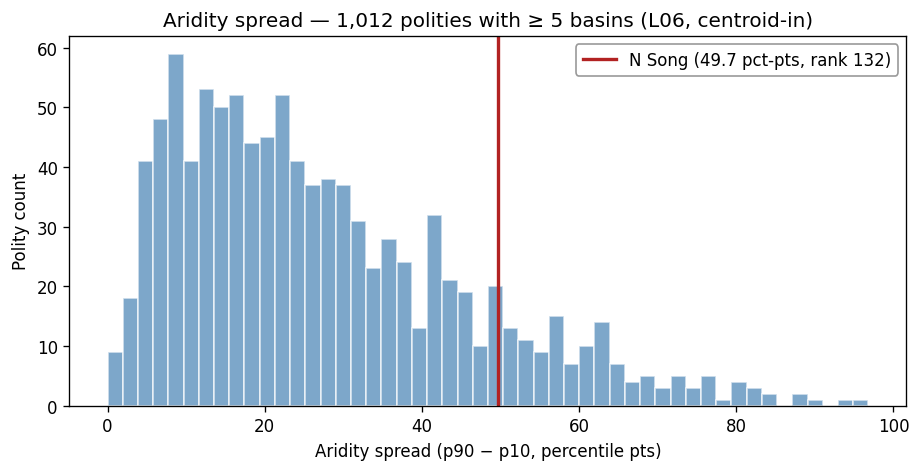

In [12]:
# Cell 7 — precipitation and elevation rankings; aridity spread distribution chart

for var, label in [('precip', 'PRECIPITATION'), ('elev', 'ELEVATION')]:
    ranked = rollup(per_slice, var)
    cols = ['name', f'{var}_spread', f'{var}_sd', 'n_basins', 'fromyear', 'toyear', f'{var}_min', f'{var}_max']
    print(f'\n=== {label} SPREAD — top 20 ===')
    print(ranked.head(20)[cols].to_string(index=True))
    nsong = ranked[ranked['name'] == 'Northern Song']
    if len(nsong):
        r = nsong.iloc[0]
        print(f'  N Song: rank {r["rank"]} / {len(ranked)}  spread={r[f"{var}_spread"]:.2f}')

# Spread distribution: where does N Song sit in the aridity spread histogram?
# PyCharm dark theme injects white into text — set color='black' on all text elements.
fig, ax = plt.subplots(figsize=(9, 4))
spread_vals = aridity_ranked['aridity_spread'].dropna()
ax.hist(spread_vals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')

nsong_row = aridity_ranked[aridity_ranked['name'] == 'Northern Song']
if len(nsong_row):
    nsong_val = nsong_row.iloc[0]['aridity_spread']
    ax.axvline(nsong_val, color='firebrick', linewidth=2,
               label=f'N Song ({nsong_val:.1f} pct-pts, rank {nsong_row.iloc[0]["rank"]})')
    ax.legend(labelcolor='black', facecolor='white', edgecolor='gray')

ax.set_xlabel('Aridity spread (p90 − p10, percentile pts)', color='black')
ax.set_ylabel('Polity count', color='black')
ax.set_title(f'Aridity spread — {len(spread_vals):,} polities with ≥ {MIN_BASINS} basins (L06, centroid-in)',
             color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

OUT_fig = OUT / 'wo1_aridity_spread_dist.png'
fig.savefig(OUT_fig, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)

from IPython.display import Image as IPImage
display(IPImage(str(OUT_fig)))

In [13]:
# Cell 8 — save TSVs
# Full ranked table (all polities >= MIN_BASINS) per variable.
# Filename encodes the level and membership rule so outputs are self-describing.

for var in ('aridity', 'precip', 'elev'):
    ranked = rollup(per_slice, var)
    path = OUT / f'wo1_polity_spread_{var}_L06_centroid.tsv'
    ranked.to_csv(path, sep='\t', index=False)
    print(f'Saved {path.name}  ({len(ranked):,} rows)')

conn.close()
print('\nDone.')

Saved wo1_polity_spread_aridity_L06_centroid.tsv  (1,012 rows)
Saved wo1_polity_spread_precip_L06_centroid.tsv  (1,012 rows)
Saved wo1_polity_spread_elev_L06_centroid.tsv  (1,012 rows)

Done.
